IMPORTING REQUIRED MODULES

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import regex as re

# MANUAL INSPECTION
DATA DIRTINESS
- age has missing values -5 rows(on programmatic assessment)
- region has missing values -3 rows (on programmatic assessment)

In [52]:
df=pd.read_csv(r'insurance_data.csv')

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1335 non-null   float64
 3   gender         1340 non-null   str    
 4   bmi            1340 non-null   float64
 5   bloodpressure  1340 non-null   int64  
 6   diabetic       1340 non-null   str    
 7   children       1340 non-null   int64  
 8   smoker         1340 non-null   str    
 9   region         1337 non-null   str    
 10  claim          1340 non-null   float64
dtypes: float64(3), int64(4), str(4)
memory usage: 115.3 KB


WE COULD HAVE CHANGED THE DATATYPE OF AGE COLUMN BUT SINCE SOME VALUES ARE MISSING WE CANNOT FILL IT UP ALTHOUGH WE CAN DROP IT AS ONLY 5 ROWS ARE THERE 

# CATEGORIZING THE COLUMNS
numerical-index,patientid,age,bmi,bloodpressure,claim

categorical-gender,diabetic,smoker,region,children

In [54]:
df['children'].value_counts()

children
0    576
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [55]:
df.duplicated().sum()

np.int64(0)

# UNIVARIATE ANALYSIS ON AGE COLUMN
## conclusions
- all 18 year old (min age) were males
- all 60 year olds(max age) were females
- age column is almost normally distributed
- age has no outlier
- all 53 year olds(the grp with least members) were females
- 5 age rows have no values

In [56]:
df['age'].describe()

count    1335.000000
mean       38.078652
std        11.102924
min        18.000000
25%        29.000000
50%        38.000000
75%        47.000000
max        60.000000
Name: age, dtype: float64

In [57]:
df.query("age==18")
#all 18 year olds were male

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
22,22,23,18.0,male,35.5,100,Yes,0,No,southeast,1532.47
41,41,42,18.0,male,27.8,93,No,0,No,northwest,1635.73
152,152,153,18.0,male,27.6,94,Yes,0,No,northwest,2523.17
244,244,245,18.0,male,25.5,99,Yes,0,No,northeast,3645.09
259,259,260,18.0,male,30.9,92,No,2,No,northwest,3877.30
326,326,327,18.0,male,30.8,97,Yes,0,No,southwest,4646.76
462,462,463,18.0,male,29.8,97,No,2,No,southeast,6406.41
517,517,518,18.0,male,36.0,93,No,2,No,southeast,7160.33
564,564,565,18.0,male,26.6,95,No,1,No,southeast,7742.11
580,580,581,18.0,male,32.0,81,Yes,2,No,northwest,8116.27


In [58]:
df.query("age==60")
#all 60 year(max age) olds were females

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
63,63,64,60.0,female,20.6,90,No,0,No,southwest,1731.68
178,178,179,60.0,female,32.1,98,No,2,No,southeast,2801.26
200,200,201,60.0,female,25.8,100,Yes,0,No,southwest,3161.45
225,225,226,60.0,female,29.9,82,Yes,1,No,southeast,3392.98
324,324,325,60.0,female,26.7,94,No,0,No,northwest,4571.41
350,350,351,60.0,female,26.2,99,No,0,No,southwest,4883.87
499,499,500,60.0,female,19.5,95,No,2,No,northwest,6933.24
534,534,535,60.0,female,35.6,80,No,1,No,southeast,7345.73
571,571,572,60.0,female,23.3,87,Yes,3,No,northeast,7986.48
617,617,618,60.0,female,36.0,90,No,1,No,southwest,8556.91


In [59]:
df['age'].skew() #almost normally distributed

np.float64(0.11361133741072633)

<Axes: ylabel='Frequency'>

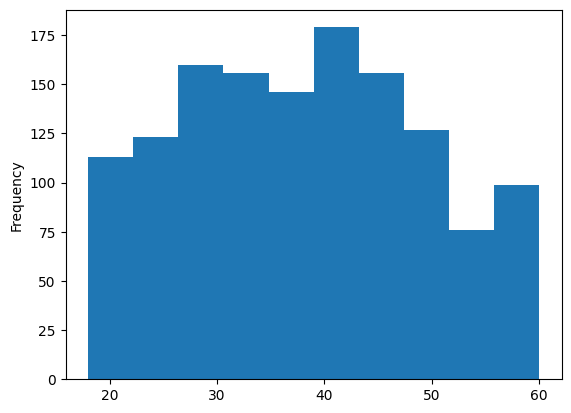

In [60]:
df['age'].plot(kind='hist')

<Axes: xlabel='age', ylabel='Density'>

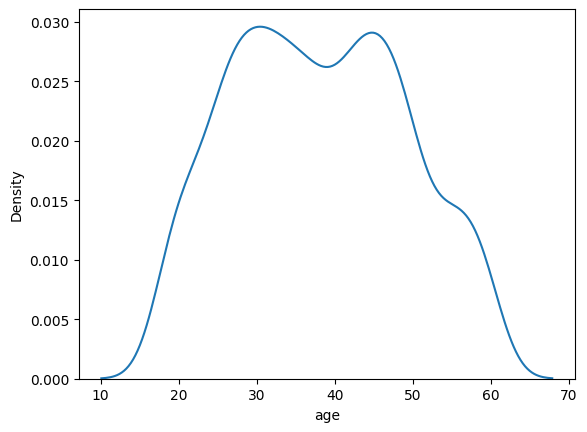

In [61]:
sns.kdeplot(data=df,x='age')

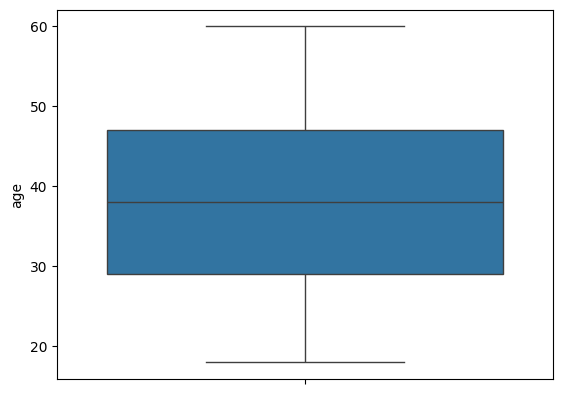

In [62]:
sns.boxplot(data=df, y='age')
plt.show()

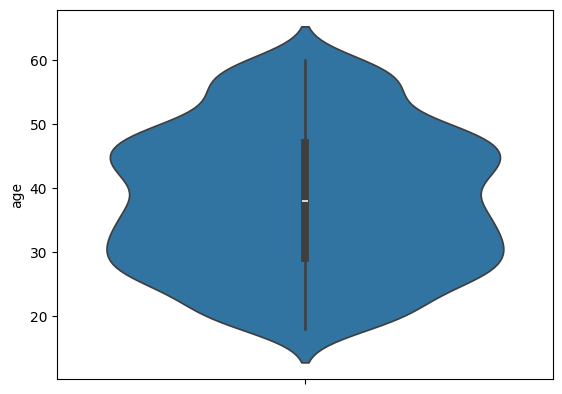

In [63]:
sns.violinplot(data=df, y='age')
plt.show()

In [64]:
df['age'].isnull().sum()

np.int64(5)

In [65]:
df['age'].value_counts()

age
43.0    50
26.0    47
30.0    44
32.0    44
46.0    44
40.0    42
37.0    41
27.0    41
48.0    40
45.0    40
34.0    39
29.0    39
49.0    38
31.0    38
36.0    37
42.0    37
47.0    37
35.0    36
28.0    36
44.0    35
33.0    35
50.0    32
38.0    32
25.0    32
19.0    29
23.0    28
39.0    26
20.0    26
55.0    26
41.0    24
22.0    24
59.0    22
60.0    21
57.0    21
21.0    18
52.0    18
56.0    18
58.0    17
51.0    17
54.0    17
24.0    16
18.0    16
53.0    15
Name: count, dtype: int64

In [66]:
df.query('age==53')
#this is the age with least members and all are females

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
79,79,80,53.0,female,33.0,83,Yes,0,No,southeast,1880.07
125,125,126,53.0,female,37.3,88,Yes,1,No,southeast,2219.45
222,222,223,53.0,female,19.8,93,Yes,1,No,southwest,3378.91
266,266,267,53.0,female,28.9,93,No,0,No,southeast,3972.92
469,469,470,53.0,female,29.8,99,No,1,No,southeast,6500.24
574,574,575,53.0,female,27.7,88,Yes,0,No,northwest,8026.67
697,697,698,53.0,female,30.8,105,No,1,No,northeast,9778.35
732,732,733,53.0,female,31.2,86,Yes,0,No,southeast,10338.93
777,777,778,53.0,female,25.3,104,Yes,0,No,southwest,11070.54
928,928,929,53.0,female,29.9,87,No,0,No,southeast,13457.96


In [67]:
df.query('age==38')

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
76,76,77,38.0,male,28.4,87,No,1,No,southwest,1842.52
199,199,200,38.0,male,23.8,99,Yes,2,No,northwest,3077.10
265,265,266,38.0,female,31.3,86,Yes,1,No,northwest,3956.07
344,344,345,38.0,female,39.8,85,Yes,1,No,southeast,4795.66
355,355,356,38.0,male,30.1,87,No,5,No,southeast,4915.06
374,374,375,38.0,female,26.1,81,Yes,0,No,southeast,5227.99
412,412,413,38.0,male,33.6,100,Yes,0,No,southeast,5699.84
429,429,430,38.0,male,34.1,90,No,0,No,southwest,5979.73
431,431,432,38.0,male,29.4,96,No,4,No,southwest,6059.17
435,435,436,38.0,female,34.1,93,No,1,No,northwest,6112.35


In [68]:
df.query('age==47')

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
35,35,36,47.0,female,38.3,93,No,0,No,southeast,1631.82
59,59,60,47.0,male,33.8,90,No,1,No,southeast,1725.55
98,98,99,47.0,male,32.1,81,No,0,No,northwest,2055.32
114,114,115,47.0,female,25.1,80,No,0,No,southeast,2196.47
133,133,134,47.0,male,35.4,95,No,0,No,southeast,2322.62
134,134,135,47.0,female,28.4,87,Yes,1,No,southwest,2331.52
140,140,141,47.0,male,35.2,80,No,1,No,southwest,2416.96
146,146,147,47.0,female,34.0,84,No,0,No,southeast,2473.33
162,162,163,47.0,male,17.7,92,Yes,0,No,northwest,2680.95
240,240,241,47.0,female,33.6,84,Yes,2,No,northwest,3579.83


# UNIVARIATE ANALYSIS ON BMI COLUMN
## CONCLUSION
- THE PERSON WITH MAX BMI AND MIN BMI BOTH ARE MALES 
- THE DATA IS NORMALLY DISTRIBUTED
- THERE ARE SOME OUTLIERS
- NO NULL VALUES

In [69]:
df['bmi'].describe()

count    1340.000000
mean       30.668955
std         6.106735
min        16.000000
25%        26.275000
50%        30.400000
75%        34.700000
max        53.100000
Name: bmi, dtype: float64

In [70]:
df.query('bmi==16')

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
48,48,49,34.0,male,16.0,83,No,0,No,northeast,1694.8


In [71]:
df.query('bmi==53.1')

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
9,9,10,30.0,male,53.1,97,No,0,No,northwest,1163.46


<Axes: ylabel='Frequency'>

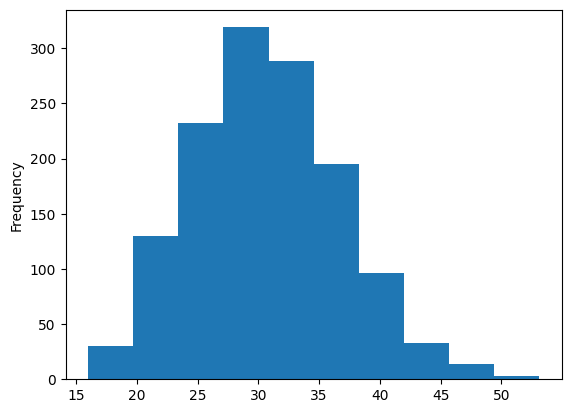

In [72]:
df['bmi'].plot(kind='hist')

<Axes: xlabel='bmi', ylabel='Density'>

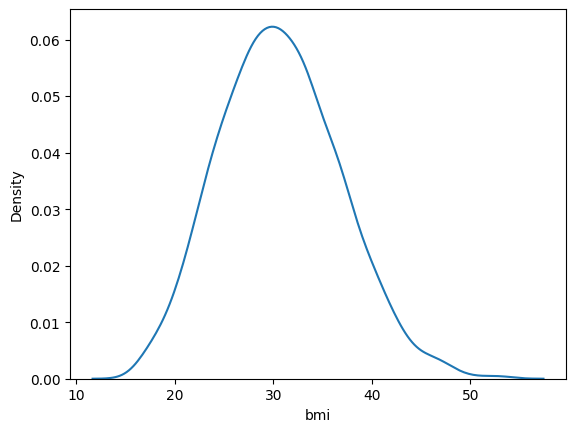

In [73]:
sns.kdeplot(data=df,x='bmi')

In [74]:
df.bmi.skew()

np.float64(0.28597245020808587)

<Axes: xlabel='bmi'>

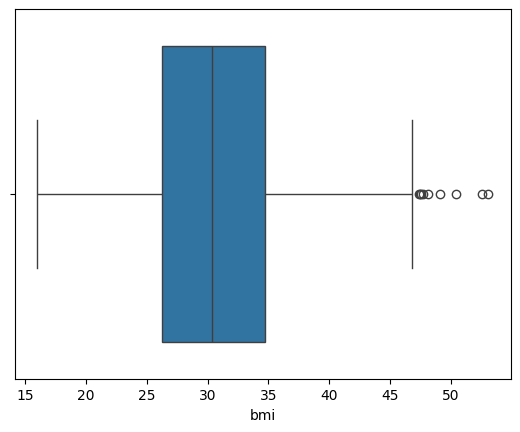

In [75]:
sns.boxplot(data=df,x='bmi')

In [76]:
df.query('bmi>45')
#these are the outliers although they don't have any issues with them

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
9,9,10,30.0,male,53.1,97,No,0,No,northwest,1163.46
141,141,142,46.0,male,50.4,89,Yes,1,No,southeast,2438.06
190,190,191,28.0,male,46.5,94,No,1,No,southeast,2927.06
246,246,247,20.0,male,45.9,97,No,2,No,southwest,3693.43
331,331,332,43.0,male,46.5,83,Yes,2,No,southeast,4686.39
455,455,456,40.0,male,45.4,91,No,2,No,southeast,6356.27
464,464,465,20.0,male,46.5,89,No,3,No,southeast,6435.62
579,579,580,25.0,male,47.5,84,Yes,1,No,southeast,8083.92
618,618,619,36.0,female,45.3,96,Yes,1,No,southeast,8569.86
675,675,676,49.0,female,48.1,81,Yes,2,No,northeast,9432.93


In [77]:
df['bmi'].value_counts()

bmi
33.3    17
27.6    17
28.9    16
32.3    15
29.8    14
        ..
39.0     1
52.6     1
46.2     1
47.6     1
47.4     1
Name: count, Length: 275, dtype: int64

In [78]:
df.query('bmi==33.3')

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
19,19,20,48.0,male,33.3,91,Yes,0,No,southeast,1391.53
80,80,81,26.0,female,33.3,83,Yes,0,No,southwest,1880.49
182,182,183,27.0,female,33.3,92,Yes,0,No,northwest,2855.44
282,282,283,48.0,female,33.3,100,Yes,1,No,southeast,4151.03
406,406,407,43.0,female,33.3,94,Yes,1,No,southeast,5594.85
594,594,595,33.0,female,33.3,93,Yes,0,No,southeast,8283.68
597,597,598,20.0,male,33.3,93,Yes,1,No,northeast,8334.46
694,694,695,32.0,male,33.3,102,Yes,0,No,northeast,9722.77
734,734,735,25.0,female,33.3,80,Yes,2,No,northeast,10370.91


In [79]:
df['bmi'].duplicated().sum()

np.int64(1065)